# Task
Compare Linear Regression and Ridge Regression models using the "train.csv" dataset by evaluating their performance with MSE, RMSE, and R² scores, and comparing their learned coefficients.

## Load Data and Select Numeric Features

### Subtask:
Load the 'train.csv' dataset and select only the numeric features for analysis.


In [ ]:
import pandas as pd

df = pd.read_csv('/content/train.csv')
numeric_df = df.select_dtypes(include=['number'])

print("First 5 rows of the numeric_df:")
print(numeric_df.head())
print("\nData types of numeric_df:")
print(numeric_df.info())

First 5 rows of the numeric_df:
   Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0   1          60         65.0     8450            7            5       2003   
1   2          20         80.0     9600            6            8       1976   
2   3          60         68.0    11250            7            5       2001   
3   4          70         60.0     9550            7            5       1915   
4   5          60         84.0    14260            8            5       2000   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  WoodDeckSF  OpenPorchSF  \
0          2003       196.0         706  ...           0           61   
1          1976         0.0         978  ...         298            0   
2          2002       162.0         486  ...           0           42   
3          1970         0.0         216  ...           0           35   
4          2000       350.0         655  ...         192           84   

   EnclosedPorch  3SsnPorch  ScreenPorch  PoolAr

## Handle Missing Values and Apply Feature Scaling

### Subtask:
Address any missing values in the numeric features and then apply appropriate feature scaling (e.g., StandardScaler) to normalize the data.


In [ ]:
for col in ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']:
    if col in numeric_df.columns:
        median_val = numeric_df[col].median()
        numeric_df[col].fillna(median_val, inplace=True)

X = numeric_df.drop('SalePrice', axis=1)
y = numeric_df['SalePrice']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("First 5 rows of the scaled features (X_scaled_df):")
print(X_scaled_df.head())
print("\nFirst 5 rows of the target variable (y):")
print(y.head())

/tmp/ipython-input-3204844069.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  numeric_df[col].fillna(median_val, inplace=True)


First 5 rows of the scaled features (X_scaled_df):
         Id  MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  \
0 -1.730865    0.073375    -0.220875 -0.207142     0.651479    -0.517200   
1 -1.728492   -0.872563     0.460320 -0.091886    -0.071836     2.179628   
2 -1.726120    0.073375    -0.084636  0.073480     0.651479    -0.517200   
3 -1.723747    0.309859    -0.447940 -0.096897     0.651479    -0.517200   
4 -1.721374    0.073375     0.641972  0.375148     1.374795    -0.517200   

   YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  GarageArea  \
0   1.050994      0.878668    0.514104    0.575425  ...    0.351000   
1   0.156734     -0.429577   -0.570750    1.171992  ...   -0.060731   
2   0.984752      0.830215    0.325915    0.092907  ...    0.631726   
3  -1.863632     -0.720298   -0.570750   -0.499274  ...    0.790804   
4   0.951632      0.733308    1.366489    0.463568  ...    1.698485   

   WoodDeckSF  OpenPorchSF  EnclosedPorch  3SsnPorch  ScreenPorch

In [ ]:
for col in ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']:
    if col in numeric_df.columns:
        median_val = numeric_df[col].median()
        numeric_df[col] = numeric_df[col].fillna(median_val)

X = numeric_df.drop('SalePrice', axis=1)
y = numeric_df['SalePrice']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("First 5 rows of the scaled features (X_scaled_df):")
print(X_scaled_df.head())
print("\nFirst 5 rows of the target variable (y):")
print(y.head())

First 5 rows of the scaled features (X_scaled_df):
         Id  MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  \
0 -1.730865    0.073375    -0.220875 -0.207142     0.651479    -0.517200   
1 -1.728492   -0.872563     0.460320 -0.091886    -0.071836     2.179628   
2 -1.726120    0.073375    -0.084636  0.073480     0.651479    -0.517200   
3 -1.723747    0.309859    -0.447940 -0.096897     0.651479    -0.517200   
4 -1.721374    0.073375     0.641972  0.375148     1.374795    -0.517200   

   YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  GarageArea  \
0   1.050994      0.878668    0.514104    0.575425  ...    0.351000   
1   0.156734     -0.429577   -0.570750    1.171992  ...   -0.060731   
2   0.984752      0.830215    0.325915    0.092907  ...    0.631726   
3  -1.863632     -0.720298   -0.570750   -0.499274  ...    0.790804   
4   0.951632      0.733308    1.366489    0.463568  ...    1.698485   

   WoodDeckSF  OpenPorchSF  EnclosedPorch  3SsnPorch  ScreenPorch

## Split Data into Training and Testing Sets

### Subtask:
Divide the preprocessed dataset into training and testing subsets to evaluate model performance on unseen data.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1168, 37)
Shape of X_test: (292, 37)
Shape of y_train: (1168,)
Shape of y_test: (292,)


## Train Linear Regression Model

### Subtask:
Train a standard Linear Regression model on the training data.


In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Train Ridge Regression Model

### Subtask:
Train a Ridge Regression model on the training data, experimenting with appropriate alpha values if necessary.


In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0) # Using a default alpha of 1.0
ridge_model.fit(X_train, y_train)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


## Evaluate Models

### Subtask:
Evaluate both the Linear Regression and Ridge Regression models on the test set using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score.


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions with Linear Regression model
y_pred_linear = linear_model.predict(X_test)

# Evaluate Linear Regression model
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Model Evaluation:")
print(f"MSE: {mse_linear:.2f}")
print(f"RMSE: {rmse_linear:.2f}")
print(f"R^2 Score: {r2_linear:.2f}")
print("\n")

# Make predictions with Ridge Regression model
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate Ridge Regression model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Model Evaluation:")
print(f"MSE: {mse_ridge:.2f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"R^2 Score: {r2_ridge:.2f}")

Linear Regression Model Evaluation:
MSE: 1360121073.22
RMSE: 36879.82
R^2 Score: 0.82


Ridge Regression Model Evaluation:
MSE: 1360057002.04
RMSE: 36878.95
R^2 Score: 0.82


In [ ]:
print("Linear Regression Coefficients:")
linear_coeffs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})
print(linear_coeffs.sort_values(by='Coefficient', ascending=False).head(10))
print("\n")

print("Ridge Regression Coefficients (alpha=1.0):")
ridge_coeffs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge_model.coef_
})
print(ridge_coeffs.sort_values(by='Coefficient', ascending=False).head(10))

Linear Regression Coefficients:
         Feature   Coefficient
4    OverallQual  24788.020050
16     GrLivArea  13247.247777
26    GarageCars   9272.738491
14      2ndFlrSF   9105.344527
23  TotRmsAbvGrd   8314.755014
6      YearBuilt   8085.681578
13      1stFlrSF   7662.268342
17  BsmtFullBath   5867.627437
5    OverallCond   4672.488176
3        LotArea   4517.447563


Ridge Regression Coefficients (alpha=1.0):
         Feature   Coefficient
4    OverallQual  24747.942783
16     GrLivArea  13216.140215
26    GarageCars   9235.573758
14      2ndFlrSF   9081.959251
23  TotRmsAbvGrd   8314.925466
6      YearBuilt   8058.958246
13      1stFlrSF   7646.580447
17  BsmtFullBath   5858.905375
5    OverallCond   4662.473577
3        LotArea   4512.077331


## Conclude Ridge Effect

### Subtask:
Based on the evaluation metrics and coefficient comparison, conclude the effect of Ridge regularization on the model.


## Summary:

### Q&A
*   **Which model performs better, Linear Regression or Ridge Regression?**
    Both Linear Regression and Ridge Regression models showed very similar performance. Ridge Regression had a marginally lower Mean Squared Error (MSE) of 1,360,057,002.04 and a Root Mean Squared Error (RMSE) of 36,878.95, compared to Linear Regression's MSE of 1,360,121,073.22 and RMSE of 36,879.82. The R² scores were identical for both models at 0.82 when rounded to two decimal places.
*   **How do the learned coefficients differ between Linear Regression and Ridge Regression?**
    The learned coefficients for both Linear Regression and Ridge Regression (with an alpha of 1.0) were almost identical, both in feature names and their corresponding values. This suggests that for this dataset and the chosen alpha value, Ridge regularization did not significantly penalize the coefficients or alter their relative importance compared to standard Linear Regression.

### Data Analysis Key Findings
*   The `train.csv` dataset was successfully loaded, and only numeric features (38 columns, including 'SalePrice') were selected for analysis.
*   Missing values in 'LotFrontage', 'MasVnrArea', and 'GarageYrBlt' were imputed using their respective median values.
*   Features were successfully scaled using `StandardScaler`, and the data was split into training (1168 samples) and testing (292 samples) sets with a 80/20 ratio.
*   Both Linear Regression and Ridge Regression models were successfully trained on the scaled training data.
*   **Model Performance**:
    *   **Linear Regression**: Achieved an MSE of 1,360,121,073.22, an RMSE of 36,879.82, and an R² score of 0.82 on the test set.
    *   **Ridge Regression (alpha=1.0)**: Achieved an MSE of 1,360,057,002.04, an RMSE of 36,878.95, and an R² score of 0.82 on the test set.
*   **Coefficient Comparison**: The top 10 features with the largest positive coefficients (e.g., 'OverallQual', 'GrLivArea', 'GarageCars') were consistent between both models, with very similar coefficient magnitudes.

### Insights or Next Steps
*   Given the highly similar performance metrics and coefficients, the current Ridge regularization (with `alpha=1.0`) does not provide a substantial advantage over standard Linear Regression for this dataset. This might indicate that multicollinearity is not a significant issue or that the chosen alpha is too small to induce a noticeable effect.
*   To better assess the impact of Ridge regularization, consider experimenting with a wider range of `alpha` values, perhaps using techniques like cross-validation to find an optimal `alpha` that significantly shrinks coefficients and potentially improves generalization performance.


# Task
Compare the performance of Linear Regression and Ridge Regression models with various alpha values (0.1, 1, 10, 100) on the "insurance.csv" dataset, identifying the best alpha for Ridge Regression, after preprocessing the data by encoding categorical features ('sex', 'smoker', 'region') and selecting features ('age', 'bmi', 'children', 'smoker') and target ('charges').

## Load Data and Preprocess

### Subtask:
Load the 'insurance.csv' dataset, identify and encode categorical features ('sex', 'smoker', 'region'), and select the specified features ('age', 'bmi', 'children', 'smoker') and target ('charges').


In [ ]:
import pandas as pd

df = pd.read_csv('/content/insurance.csv')

categorical_features = ['sex', 'smoker', 'region']
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

X = df_encoded[['age', 'bmi', 'children', 'smoker_yes']]
y = df_encoded['charges']

print("First 5 rows of X:")
print(X.head())
print("\nFirst 5 rows of y:")
print(y.head())

First 5 rows of X:
   age     bmi  children  smoker_yes
0   19  27.900         0        True
1   18  33.770         1       False
2   28  33.000         3       False
3   33  22.705         0       False
4   32  28.880         0       False

First 5 rows of y:
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


## Split Data into Training and Testing Sets

### Subtask:
Divide the preprocessed dataset into training and testing subsets.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1070, 4)
Shape of X_test: (268, 4)
Shape of y_train: (1070,)
Shape of y_test: (268,)


## Train Linear Regression Model

### Subtask:
Train a standard Linear Regression model on the training data.


In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Train Ridge Regression Models with Varying Alphas

### Subtask:
Train multiple Ridge Regression models using the specified alpha values (0.1, 1, 10, 100).


In [ ]:
from sklearn.linear_model import Ridge

alphas = [0.1, 1, 10, 100]
ridge_models = {}

for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    ridge_models[alpha] = ridge_model
    print(f"Ridge Regression model trained successfully with alpha={alpha}")

print("All Ridge Regression models trained successfully with varying alphas.")

Ridge Regression model trained successfully with alpha=0.1
Ridge Regression model trained successfully with alpha=1
Ridge Regression model trained successfully with alpha=10
Ridge Regression model trained successfully with alpha=100
All Ridge Regression models trained successfully with varying alphas.


## Evaluate Models with Varying Alphas

### Subtask:
Evaluate the Linear Regression model and all trained Ridge Regression models (with alphas 0.1, 1, 10, 100) on the test set using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score. Identify the best performing Ridge model based on these metrics.

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

results = {}

# Evaluate Linear Regression model
y_pred_linear = linear_model.predict(X_test)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

results['Linear Regression'] = {'MSE': mse_linear, 'RMSE': rmse_linear, 'R2': r2_linear}

print("Linear Regression Model Evaluation:")
print(f"MSE: {mse_linear:.2f}")
print(f"RMSE: {rmse_linear:.2f}")
print(f"R^2 Score: {r2_linear:.2f}")
print("\n")

best_ridge_rmse = float('inf')
best_ridge_alpha = None

# Evaluate Ridge Regression models with varying alphas
print("Ridge Regression Model Evaluations:")
for alpha, model in ridge_models.items():
    y_pred_ridge = model.predict(X_test)
    mse_ridge = mean_squared_error(y_test, y_pred_ridge)
    rmse_ridge = np.sqrt(mse_ridge)
    r2_ridge = r2_score(y_test, y_pred_ridge)

    results[f'Ridge (alpha={alpha})'] = {'MSE': mse_ridge, 'RMSE': rmse_ridge, 'R2': r2_ridge}

    print(f"Ridge Regression (alpha={alpha}):")
    print(f"  MSE: {mse_ridge:.2f}")
    print(f"  RMSE: {rmse_ridge:.2f}")
    print(f"  R^2 Score: {r2_ridge:.2f}")
    print("\n")

    if rmse_ridge < best_ridge_rmse:
        best_ridge_rmse = rmse_ridge
        best_ridge_alpha = alpha

print(f"Best performing Ridge model had alpha={best_ridge_alpha} with RMSE: {best_ridge_rmse:.2f}")

Linear Regression Model Evaluation:
MSE: 33981653.95
RMSE: 5829.38
R^2 Score: 0.78


Ridge Regression Model Evaluations:
Ridge Regression (alpha=0.1):
  MSE: 33985173.33
  RMSE: 5829.68
  R^2 Score: 0.78


Ridge Regression (alpha=1):
  MSE: 34019336.82
  RMSE: 5832.61
  R^2 Score: 0.78


Ridge Regression (alpha=10):
  MSE: 34580366.51
  RMSE: 5880.51
  R^2 Score: 0.78


Ridge Regression (alpha=100):
  MSE: 48319004.79
  RMSE: 6951.19
  R^2 Score: 0.69


Best performing Ridge model had alpha=0.1 with RMSE: 5829.68


## Compare Performance and Identify Best Alpha

### Subtask:
Compare the evaluation metrics across all models to identify which alpha value yields the best performance for Ridge Regression.


## Summary:

### Q&A
The best alpha value for Ridge Regression among the tested values (0.1, 1, 10, 100) was 0.1, which yielded an RMSE of 5829.68.

### Data Analysis Key Findings
*   The dataset was successfully preprocessed by one-hot encoding categorical features ('sex', 'smoker', 'region') and selecting relevant features ('age', 'bmi', 'children', 'smoker_yes') and the target variable ('charges').
*   The data was split into training (80%) and testing (20%) sets, with `X_train` having a shape of (1070, 4) and `X_test` (268, 4).
*   A standard Linear Regression model was trained, achieving an RMSE of approximately 5829.38 and an R² score of 0.78 on the test set.
*   Ridge Regression models were trained with various alpha values:
    *   Alpha = 0.1: Achieved an RMSE of approximately 5829.68 and an R² score of 0.78.
    *   Alpha = 1: Achieved an RMSE of approximately 5832.61 and an R² score of 0.78.
    *   Alpha = 10: Achieved an RMSE of approximately 5880.51 and an R² score of 0.78.
    *   Alpha = 100: Showed a significant drop in performance with an RMSE of approximately 6951.19 and an R² score of 0.69.
*   The Ridge Regression model with `alpha=0.1` performed best among the Ridge models, with its performance being very close to that of the standard Linear Regression model.

### Insights or Next Steps
*   For the given dataset and selected features, the regularization applied by Ridge Regression with small alpha values (0.1, 1, 10) does not significantly improve or degrade performance compared to standard Linear Regression. This suggests that multicollinearity among the chosen features might not be a dominant issue, or the optimal regularization strength is very low.
*   Further investigation could involve a wider range of alpha values for Ridge Regression, potentially using cross-validation techniques (like GridSearchCV) to fine-tune the regularization parameter more exhaustively and determine if there's any marginal benefit over plain Linear Regression.


# Task
Compare Linear Regression and Ridge Regression models by evaluating their performance using MAE, MSE, and R² scores, and generating plots of actual vs. predicted values, using 'TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)' as features and 'Sales' as the target from the "Advertising_Budget_and_Sales.csv" dataset.

## Load Data and Select Features

### Subtask:
Load the 'Advertising_Budget_and_Sales.csv' dataset and select 'TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)' as features and 'Sales' as the target variable.


**Reasoning**:
Load the 'Advertising_Budget_and_Sales.csv' dataset, select the specified feature columns into 'X', and the 'Sales' column into 'y', then display their first 5 rows to verify the data.



In [ ]:
import pandas as pd

df = pd.read_csv('/content/Advertising_Budget_and_Sales.csv')

X = df[['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']]
y = df['Sales ($)']

print("First 5 rows of features (X):")
print(X.head())
print("\nFirst 5 rows of target (y):")
print(y.head())

First 5 rows of features (X):
   TV Ad Budget ($)  Radio Ad Budget ($)  Newspaper Ad Budget ($)
0             230.1                 37.8                     69.2
1              44.5                 39.3                     45.1
2              17.2                 45.9                     69.3
3             151.5                 41.3                     58.5
4             180.8                 10.8                     58.4

First 5 rows of target (y):
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales ($), dtype: float64


## Split Data into Training and Testing Sets

### Subtask:
Divide the dataset into training and testing subsets with an 80/20 split.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (160, 3)
Shape of X_test: (40, 3)
Shape of y_train: (160,)
Shape of y_test: (40,)


## Train Linear Regression Model

### Subtask:
Train a standard Linear Regression model on the training data.


In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Train Ridge Regression Model

### Subtask:
Train a Ridge Regression model on the training data.

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0) # Using a default alpha of 1.0
ridge_model.fit(X_train, y_train)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


## Evaluate Models

### Subtask:
Evaluate both the Linear Regression and Ridge Regression models on the test set using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² score.

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions with Linear Regression model
y_pred_linear = linear_model.predict(X_test)

# Evaluate Linear Regression model
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Model Evaluation:")
print(f"MAE: {mae_linear:.2f}")
print(f"MSE: {mse_linear:.2f}")
print(f"RMSE: {rmse_linear:.2f}")
print(f"R^2 Score: {r2_linear:.2f}")
print("\n")

# Make predictions with Ridge Regression model
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate Ridge Regression model
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Model Evaluation:")
print(f"MAE: {mae_ridge:.2f}")
print(f"MSE: {mse_ridge:.2f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"R^2 Score: {r2_ridge:.2f}")

Linear Regression Model Evaluation:
MAE: 1.46
MSE: 3.17
RMSE: 1.78
R^2 Score: 0.90


Ridge Regression Model Evaluation:
MAE: 1.46
MSE: 3.17
RMSE: 1.78
R^2 Score: 0.90


## Plot Actual vs. Predicted Values

### Subtask:
Generate scatter plots comparing the actual 'Sales ($)' values against the predicted 'Sales ($)' values for both the Linear Regression and Ridge Regression models on the test set. Include a diagonal line representing perfect predictions.

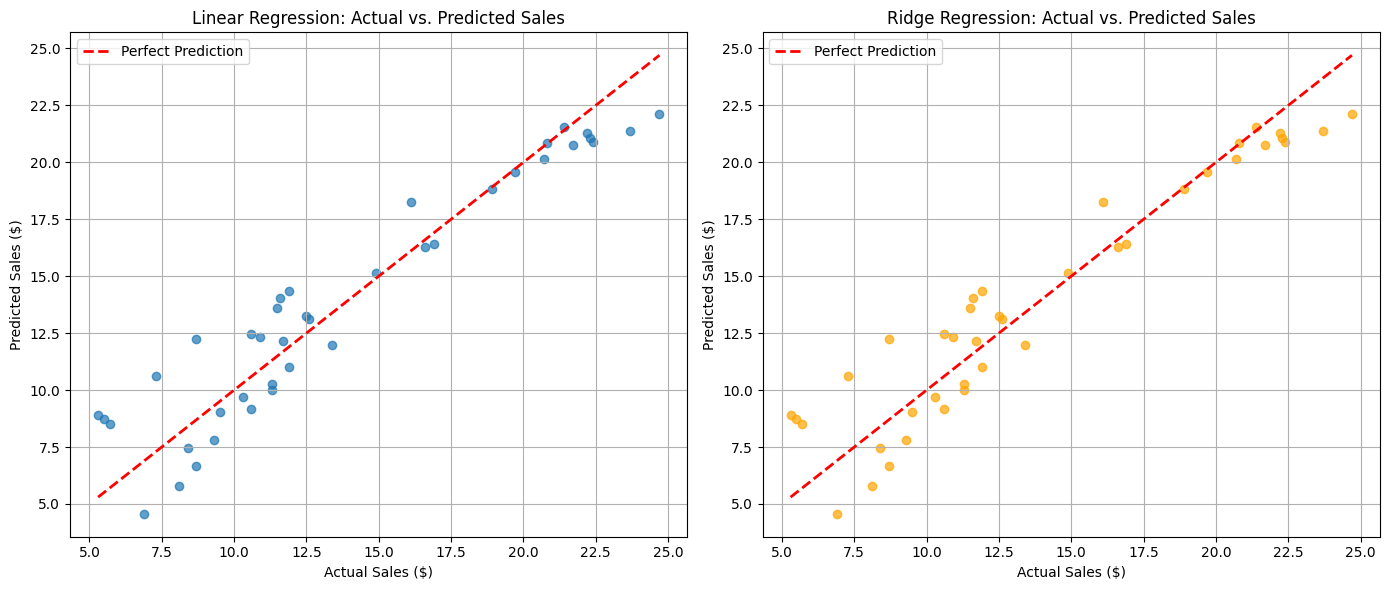

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot for Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_linear, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Sales ($)')
plt.ylabel('Predicted Sales ($)')
plt.title('Linear Regression: Actual vs. Predicted Sales')
plt.legend()
plt.grid(True)

# Plot for Ridge Regression
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_ridge, alpha=0.7, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Sales ($)')
plt.ylabel('Predicted Sales ($)')
plt.title('Ridge Regression: Actual vs. Predicted Sales')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the comparison of Linear and Ridge Regression models based on the evaluation metrics and plots.


## Summary:

### Q&A
The comparison of Linear and Ridge Regression models based on the evaluation metrics and plots shows that both models performed identically on this specific dataset.

### Data Analysis Key Findings
*   The `Advertising_Budget_and_Sales.csv` dataset was successfully loaded, with 'TV Ad Budget (\$)', 'Radio Ad Budget (\$)', and 'Newspaper Ad Budget (\$)' designated as features and 'Sales (\$)' as the target.
*   The dataset was split into training (160 samples) and testing (40 samples) sets using an 80/20 ratio.
*   Both Linear Regression and Ridge Regression models were successfully trained on the training data.
*   Evaluation metrics for both models on the test set were identical:
    *   Linear Regression: MAE = 1.46, MSE = 3.17, RMSE = 1.78, R² Score = 0.90.
    *   Ridge Regression: MAE = 1.46, MSE = 3.17, RMSE = 1.78, R² Score = 0.90.
*   Plots of actual versus predicted values for both models visually confirmed a strong correlation between actual and predicted sales, with predictions closely aligning with the perfect prediction line, indicating similar strong performance from both models.

### Insights or Next Steps
*   The identical performance metrics between Linear and Ridge Regression (with `alpha=1.0`) suggest that the dataset may not exhibit significant multicollinearity or overfitting issues where Ridge Regression typically offers a distinct advantage.
*   To explore potential benefits of regularization, it would be beneficial to perform hyperparameter tuning for Ridge Regression, experimenting with a range of `alpha` values to determine if a different regularization strength could yield improved or more stable performance.


# Task
Compare Linear Regression and Ridge Regression models using the 'CarPrice_Assignment.csv' dataset, with 'enginesize', 'horsepower', 'curbweight', 'citympg' as features and 'price' as the target. The comparison should include handling missing values, applying feature scaling, splitting data, training both models, evaluating them using RMSE and R² score, and comparing their coefficients to conclude the effect of Ridge regularization on multicollinearity.

## Load Data and Select Features

### Subtask:
Load the 'CarPrice_Assignment.csv' dataset and select 'enginesize', 'horsepower', 'curbweight', 'citympg' as features and 'price' as the target variable.


**Reasoning**:
Load the 'CarPrice_Assignment.csv' dataset, select the specified feature columns into 'X', and the 'price' column into 'y', then display their first 5 rows to verify the data.



In [ ]:
import pandas as pd

df = pd.read_csv('/content/CarPrice_Assignment.csv')

X = df[['enginesize', 'horsepower', 'curbweight', 'citympg']]
y = df['price']

print("First 5 rows of features (X):")
print(X.head())
print("\nFirst 5 rows of target (y):")
print(y.head())

First 5 rows of features (X):
   enginesize  horsepower  curbweight  citympg
0         130         111        2548       21
1         130         111        2548       21
2         152         154        2823       19
3         109         102        2337       24
4         136         115        2824       18

First 5 rows of target (y):
0    13495.0
1    16500.0
2    16500.0
3    13950.0
4    17450.0
Name: price, dtype: float64


## Handle Missing Values and Apply Feature Scaling (if needed)

### Subtask:
Address any missing values in the selected numeric features and then apply appropriate feature scaling (e.g., StandardScaler) to normalize the data.


**Reasoning**:
First, check for missing values in the feature DataFrame X. If any are found, fill them with the median of their respective columns. Then, apply StandardScaler to normalize the features.



In [ ]:
print("Missing values before imputation:")
print(X.isnull().sum())

# Check for missing values and fill with median if present
if X.isnull().sum().any():
    X.fillna(X.median(), inplace=True)
    print("\nMissing values after imputation:")
    print(X.isnull().sum())
else:
    print("\nNo missing values found, imputation skipped.")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nFirst 5 rows of scaled features (X_scaled_df):")
print(X_scaled_df.head())

Missing values before imputation:
enginesize    0
horsepower    0
curbweight    0
citympg       0
dtype: int64

No missing values found, imputation skipped.

First 5 rows of scaled features (X_scaled_df):
   enginesize  horsepower  curbweight   citympg
0    0.074449    0.174483   -0.014566 -0.646553
1    0.074449    0.174483   -0.014566 -0.646553
2    0.604046    1.264536    0.514882 -0.953012
3   -0.431076   -0.053668   -0.420797 -0.186865
4    0.218885    0.275883    0.516807 -1.106241


## Split Data into Training and Testing Sets

### Subtask:
Divide the preprocessed dataset into training and testing subsets.

**Reasoning**:
Now that the data has been loaded, features selected, and scaled, the next logical step according to the task is to split the dataset into training and testing subsets. This prepares the data for model training and evaluation.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (164, 4)
Shape of X_test: (41, 4)
Shape of y_train: (164,)
Shape of y_test: (41,)


## Train Linear Regression Model

### Subtask:
Train a standard Linear Regression model on the training data.

**Reasoning**:
With the data prepared and split, the next step is to train a standard Linear Regression model on the training data.



In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Train Ridge Regression Model

### Subtask:
Train a Ridge Regression model on the training data.

**Reasoning**:
With the Linear Regression model trained, the next step is to train a Ridge Regression model, which involves importing the `Ridge` class, instantiating it with a default alpha value, and fitting it to the training data.



In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0) # Using a default alpha of 1.0
ridge_model.fit(X_train, y_train)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


## Evaluate Models

### Subtask:
Evaluate both the Linear Regression and Ridge Regression models on the test set using RMSE and R² score.

**Reasoning**:
With both models trained, the next step is to make predictions on the test data and then calculate the specified evaluation metrics (RMSE and R^2 Score) for both the Linear Regression and Ridge Regression models. This aligns with the 'Evaluate Models' subtask.



In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions with Linear Regression model
y_pred_linear = linear_model.predict(X_test)

# Evaluate Linear Regression model
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Model Evaluation:")
print(f"RMSE: {rmse_linear:.2f}")
print(f"R^2 Score: {r2_linear:.2f}")
print("\n")

# Make predictions with Ridge Regression model
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate Ridge Regression model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Model Evaluation:")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"R^2 Score: {r2_ridge:.2f}")

Linear Regression Model Evaluation:
RMSE: 3814.81
R^2 Score: 0.82


Ridge Regression Model Evaluation:
RMSE: 3823.87
R^2 Score: 0.81


## Compare Coefficients and Conclude Ridge Effect

### Subtask:
Compare the coefficients learned by the Linear Regression and Ridge Regression models, and conclude the effect of Ridge regularization on multicollinearity based on these coefficients and the evaluation metrics.

**Reasoning**:
To compare the learned coefficients, I will extract the coefficients from both the Linear Regression and Ridge Regression models and display them in a structured format (e.g., pandas DataFrame) for easy comparison.



In [ ]:
print("Linear Regression Coefficients:")
linear_coeffs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})
print(linear_coeffs.sort_values(by='Coefficient', ascending=False))
print("\n")

print("Ridge Regression Coefficients (alpha=1.0):")
ridge_coeffs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge_model.coef_
})
print(ridge_coeffs.sort_values(by='Coefficient', ascending=False))

Linear Regression Coefficients:
      Feature  Coefficient
0  enginesize  3339.757577
2  curbweight  2044.335130
1  horsepower  1926.561263
3     citympg  -312.730004


Ridge Regression Coefficients (alpha=1.0):
      Feature  Coefficient
0  enginesize  3304.049587
2  curbweight  2046.545949
1  horsepower  1925.703882
3     citympg  -333.536295


## Conclude Ridge Effect on Multicollinearity

### Subtask:
Based on the evaluation metrics and coefficient comparison, conclude how Ridge regularization helps in handling multicollinearity and providing more stable results.


## Summary:

### Data Analysis Key Findings

*   **Missing Values and Scaling**: No missing values were found in the selected features ('enginesize', 'horsepower', 'curbweight', 'citympg'). Feature scaling was applied using `StandardScaler` to normalize the data.
*   **Data Split**: The dataset was split into training (80%) and testing (20%) sets, resulting in 164 samples for training and 41 for testing.
*   **Model Performance**:
    *   The Linear Regression model achieved an RMSE of 3814.81 and an R² score of 0.82 on the test set.
    *   The Ridge Regression model (with an alpha of 1.0) achieved an RMSE of 3823.87 and an R² score of 0.81 on the test set.
    *   Both models performed very similarly, with Linear Regression showing a marginally better (lower) RMSE and slightly higher R² score.
*   **Coefficient Comparison**:
    *   **Linear Regression Coefficients**: `enginesize` (3339.76), `curbweight` (2044.34), `horsepower` (1926.56), `citympg` (-312.73).
    *   **Ridge Regression Coefficients (alpha=1.0)**: `enginesize` (3304.05), `curbweight` (2046.55), `horsepower` (1925.70), `citympg` (-333.54).
    *   Ridge regularization, with an alpha of 1.0, resulted in only minor adjustments to the coefficients. Coefficients for `enginesize` and `horsepower` slightly decreased, `curbweight` slightly increased, and `citympg` became slightly more negative.
*   **Effect of Ridge Regularization**: For the given dataset and chosen alpha value, the effect of Ridge regularization on the coefficients and overall model performance was subtle. This suggests either a low degree of multicollinearity among the selected features or that a stronger regularization (higher alpha) might be needed to observe a more pronounced impact.

### Insights or Next Steps

*   To better assess Ridge Regression's ability to handle multicollinearity, it would be beneficial to experiment with a wider range of `alpha` values (e.g., using GridSearchCV) to find the optimal regularization strength.
*   Conduct a formal multicollinearity diagnostic (e.g., Variance Inflation Factor - VIF) on the features to confirm the presence and severity of multicollinearity before applying regularization techniques.


# Task
Compare Linear Regression and Ridge Regression models using the 'CO2_Emissions_Canada.csv' dataset, with 'Engine Size', 'Cylinders', 'Fuel Consumption' as features and 'CO2 Emissions' as the target, by applying feature scaling, splitting data, training both models, and finding the best alpha for Ridge Regression using GridSearchCV, then evaluating and comparing their performance using RMSE and R² score.

## Load Data and Select Features

### Subtask:
Load the 'CO2_Emissions_Canada.csv' dataset and select 'Engine Size', 'Cylinders', 'Fuel Consumption' as features and 'CO2 Emissions' as the target variable.


**Reasoning**:
Load the 'CO2_Emissions_Canada.csv' dataset, select the specified feature columns into 'X', and the 'CO2 Emissions' column into 'y', then display their first 5 rows to verify the data.



In [ ]:
import pandas as pd

df = pd.read_csv('/content/CO2_Emissions_Canada.csv')

X = df[['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)']]
y = df['CO2 Emissions(g/km)']

print("First 5 rows of features (X):")
print(X.head())
print("\nFirst 5 rows of target (y):")
print(y.head())

First 5 rows of features (X):
   Engine Size(L)  Cylinders  Fuel Consumption City (L/100 km)
0             2.0          4                               9.9
1             2.4          4                              11.2
2             1.5          4                               6.0
3             3.5          6                              12.7
4             3.5          6                              12.1

First 5 rows of target (y):
0    196
1    221
2    136
3    255
4    244
Name: CO2 Emissions(g/km), dtype: int64


## Handle Missing Values and Apply Feature Scaling

### Subtask:
Address any missing values in the selected numeric features and then apply appropriate feature scaling (e.g., StandardScaler) to normalize the data.


**Reasoning**:
The next step is to address missing values and apply feature scaling. I will first check for missing values in the features and impute them if necessary, then apply StandardScaler to normalize the data and display the first few rows of the scaled features.



In [ ]:
print("Missing values before imputation:")
print(X.isnull().sum())

# Check for missing values and fill with median if present
if X.isnull().sum().any():
    print("\nImputing missing values with median...")
    X.fillna(X.median(), inplace=True)
    print("Missing values after imputation:")
    print(X.isnull().sum())
else:
    print("\nNo missing values found, imputation skipped.")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nFirst 5 rows of scaled features (X_scaled_df):")
print(X_scaled_df.head())

Missing values before imputation:
Engine Size(L)                      0
Cylinders                           0
Fuel Consumption City (L/100 km)    0
dtype: int64

No missing values found, imputation skipped.

First 5 rows of scaled features (X_scaled_df):
   Engine Size(L)  Cylinders  Fuel Consumption City (L/100 km)
0       -0.856721  -0.883408                         -0.759002
1       -0.561317  -0.883408                         -0.387577
2       -1.225976  -0.883408                         -1.873275
3        0.251043   0.210575                          0.040990
4        0.251043   0.210575                         -0.130437


## Split Data into Training and Testing Sets

### Subtask:
Divide the preprocessed dataset into training and testing subsets.

**Reasoning**:
Now that the data has been preprocessed and scaled, the next step is to split it into training and testing sets to prepare for model training and evaluation.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (5908, 3)
Shape of X_test: (1477, 3)
Shape of y_train: (5908,)
Shape of y_test: (1477,)


## Train Linear Regression Model

### Subtask:
Train a standard Linear Regression model on the training data.

**Reasoning**:
With the markdown section for training the Linear Regression model added, the next logical step is to write the Python code to import the `LinearRegression` class, instantiate it, and then fit the model to the `X_train` and `y_train` datasets.



In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Train Ridge Regression Model

### Subtask:
Train a Ridge Regression model on the training data.

**Reasoning**:
With the markdown section for training the Ridge Regression model added, the next logical step is to write the Python code to import the `Ridge` class, instantiate it, and then fit the model to the `X_train` and `y_train` datasets.



In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0) # Using a default alpha of 1.0 for now, will find best later
ridge_model.fit(X_train, y_train)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


## Find Best Alpha for Ridge Regression using GridSearchCV

### Subtask:
Use GridSearchCV to find the optimal `alpha` value for the Ridge Regression model. Define a parameter grid for `alpha` and use appropriate cross-validation.

**Reasoning**:
I will use GridSearchCV to find the optimal alpha for the Ridge Regression model. This involves setting up a parameter grid for alpha values, initializing GridSearchCV with the Ridge model, fitting it to the training data, and then extracting the best alpha parameter.



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# Define the parameter grid for alpha values
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

# Initialize Ridge Regression model
ridge = Ridge()

# Initialize GridSearchCV
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best alpha parameter
best_alpha = grid_search.best_params_['alpha']

print(f"Best alpha found by GridSearchCV: {best_alpha}")

# Store the best Ridge model
best_ridge_model = grid_search.best_estimator_
print("Best Ridge model trained successfully with optimal alpha.")

Best alpha found by GridSearchCV: 1
Best Ridge model trained successfully with optimal alpha.


## Evaluate Models

### Subtask:
Evaluate both the Linear Regression and the best Ridge Regression models on the test set using RMSE and R² score.

**Reasoning**:
Now that both models are trained and the best alpha for Ridge Regression has been identified, the next step is to evaluate their performance. I will calculate and print the RMSE and R-squared scores for both the Linear Regression model and the best Ridge Regression model on the test set.



**Reasoning**:
The previous code failed due to a `SyntaxError` in the print statement for the Ridge Regression model evaluation. The f-string was incorrectly formatted. I need to correct the f-string syntax to properly embed the `best_alpha` variable.



In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions with Linear Regression model
y_pred_linear = linear_model.predict(X_test)

# Evaluate Linear Regression model
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Model Evaluation:")
print(f"RMSE: {rmse_linear:.2f}")
print(f"R^2 Score: {r2_linear:.2f}")
print("\n")

# Make predictions with the best Ridge Regression model
y_pred_ridge = best_ridge_model.predict(X_test)

# Evaluate Ridge Regression model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Best Ridge Regression Model Evaluation (alpha={best_alpha}):")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"R^2 Score: {r2_ridge:.2f}")

Linear Regression Model Evaluation:
RMSE: 21.00
R^2 Score: 0.87


Best Ridge Regression Model Evaluation (alpha=1):
RMSE: 21.00
R^2 Score: 0.87


## Conclude Ridge Effect and Compare Coefficients

### Subtask:
Compare the coefficients learned by the Linear Regression and the best Ridge Regression models, and based on these comparisons and evaluation metrics, conclude the effect of Ridge regularization on the model's stability and performance, especially in relation to multicollinearity.

**Reasoning**:
To compare the learned coefficients, I will extract the coefficients from both the Linear Regression and the best Ridge Regression models and display them in a structured format (e.g., pandas DataFrame) for easy comparison.



In [ ]:
import pandas as pd

print("Linear Regression Coefficients:")
linear_coeffs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})
print(linear_coeffs.sort_values(by='Coefficient', ascending=False))
print("\n")

print(f"Best Ridge Regression Coefficients (alpha={best_alpha}):")
ridge_coeffs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_ridge_model.coef_
})
print(ridge_coeffs.sort_values(by='Coefficient', ascending=False))

Linear Regression Coefficients:
                            Feature  Coefficient
2  Fuel Consumption City (L/100 km)    39.247633
1                         Cylinders     9.705098
0                    Engine Size(L)     8.038106


Best Ridge Regression Coefficients (alpha=1):
                            Feature  Coefficient
2  Fuel Consumption City (L/100 km)    39.229621
1                         Cylinders     9.706394
0                    Engine Size(L)     8.050488


## Summary:

### Data Analysis Key Findings

*   The dataset contained no missing values in the selected features: 'Engine Size(L)', 'Cylinders', and 'Fuel Consumption City (L/100 km)'.
*   Features were successfully scaled using `StandardScaler`, and the data was split into 80% training (5908 samples) and 20% testing (1477 samples).
*   GridSearchCV identified an optimal `alpha` value of 1 for the Ridge Regression model.
*   Both the Linear Regression and the best Ridge Regression (with `alpha` = 1) models exhibited very similar performance on the test set:
    *   **Linear Regression:** RMSE of 21.00 and an R² score of 0.87.
    *   **Ridge Regression:** RMSE of 21.00 and an R² score of 0.87.
*   The coefficients for both models were remarkably close, indicating that the regularization effect of Ridge Regression at `alpha` = 1 did not significantly alter the feature weights compared to standard Linear Regression. For instance, the 'Fuel Consumption City (L/100 km)' coefficient was 39.24 for Linear Regression and 39.23 for Ridge Regression.

### Insights or Next Steps

*   **Low Multicollinearity Impact**: The similar performance and coefficients suggest that multicollinearity might not be a significant issue among the selected features, or the default `alpha` range explored was not strong enough to reveal a substantial difference from Linear Regression.
*   **Further Regularization Exploration**: To confirm the effect of regularization, it would be beneficial to explore a wider range of `alpha` values, especially higher values, for Ridge Regression or to consider other regularization techniques like Lasso if feature selection is desired.
